In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training dataset
df_train = pd.read_csv('train.csv')
# Display the first few rows to understand the structure
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Load the test dataset for final predictions
df_test = pd.read_csv('test.csv')
# Display the first few rows of the test data
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
# Set pandas to show all rows in output for checking missing values
pd.set_option('display.max_rows', None)
# Calculate sum of missing values per column
missing = df_train.isnull().sum()
# Filter and show only columns that have at least one missing value
missing[missing > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


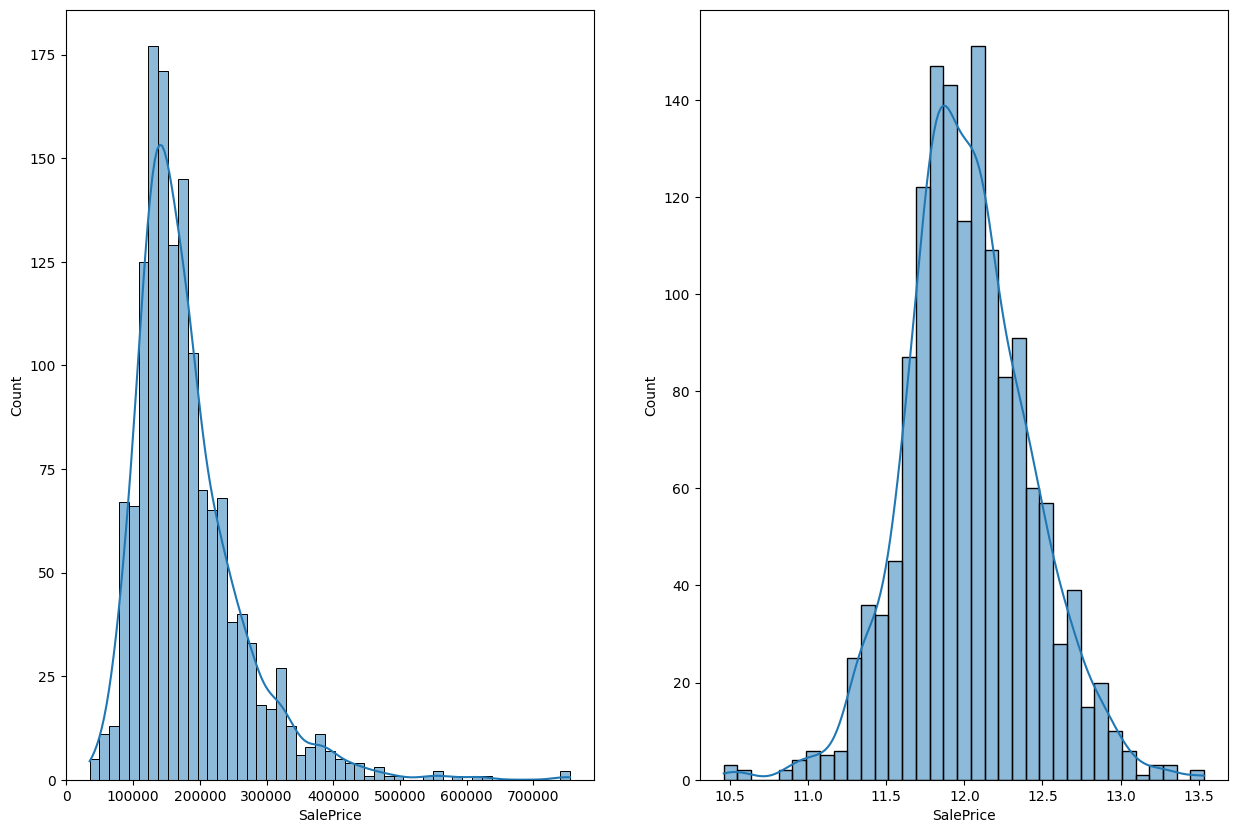

In [ ]:
# Visualize the distribution of the target variable 'SalePrice'
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
# Plot original SalePrice distribution (usually right-skewed)
sns.histplot(df_train["SalePrice"], kde=True, ax=axes[0])
# Plot log-transformed SalePrice to see if it becomes more normally distributed
sns.histplot(np.log1p(df_train["SalePrice"]), kde=True, ax=axes[1])
plt.show()

In [ ]:
# Fill missing values in 'LotFrontage' with the mean of the column
df_train["LotFrontage"].fillna(df_train["LotFrontage"].mean(), inplace=True)
# Verify that there are no more missing values in this column
df_train["LotFrontage"].isna().sum()

/tmp/ipykernel_9972/1969583772.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["LotFrontage"].fillna(df_train["LotFrontage"].mean(), inplace=True)


np.int64(0)

In [ ]:
# Fill missing 'Alley' values with 'None' as per data description
df_train["Alley"].fillna("None", inplace=True)
# Verify missing values are handled
df_train["Alley"].isna().sum()

/tmp/ipykernel_9972/3378911918.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Alley"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Fill missing 'MasVnrType' with 'None'
df_train["MasVnrType"].fillna("None", inplace=True)
# Verify result
df_train["MasVnrType"].isna().sum()

/tmp/ipykernel_9972/3447519579.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["MasVnrType"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Fill missing masonry veneer area with the median value
df_train["MasVnrArea"].fillna(df_train["MasVnrArea"].median(), inplace=True)

/tmp/ipykernel_9972/2636207248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["MasVnrArea"].fillna(df_train["MasVnrArea"].median(), inplace=True)


In [ ]:
# Fill missing basement quality with 'None'
df_train["BsmtQual"].fillna("None", inplace=True)
# Verify result
df_train["BsmtQual"].isna().sum()

/tmp/ipykernel_9972/2138545893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["BsmtQual"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Define a manual mapping for ordinal encoding of basement quality
encoder_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
# Map the categorical strings to numeric ranks
df_train["BsmtQual"] = df_train["BsmtQual"].map(encoder_map)
# Verify no NaNs were introduced during mapping
df_train["BsmtQual"].isna().sum()

np.int64(0)

In [ ]:
# Handle basement condition: fill missing and map to ordinal values
df_train["BsmtCond"].fillna("None", inplace=True)
encoder_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
df_train["BsmtCond"] = df_train["BsmtCond"].map(encoder_map)
# Verify mapping
df_train["BsmtCond"].isna().sum()

/tmp/ipykernel_9972/3993992230.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["BsmtCond"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Handle basement exposure: fill missing and map to ordinal values
df_train["BsmtExposure"].fillna("None", inplace=True)
encoder_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df_train["BsmtExposure"] = df_train["BsmtExposure"].map(encoder_map)
df_train["BsmtExposure"].isna().sum()

/tmp/ipykernel_9972/3317568391.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["BsmtExposure"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Handle basement finish type 1: fill missing and map to ordinal values
df_train["BsmtFinType1"].fillna("None", inplace=True)
encoder_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df_train["BsmtFinType1"] = df_train["BsmtFinType1"].map(encoder_map)
df_train["BsmtFinType1"].isna().sum()

/tmp/ipykernel_9972/2065192021.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["BsmtFinType1"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Handle basement finish type 2: fill missing and map to ordinal values
df_train["BsmtFinType2"].fillna("None", inplace=True)
encoder_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df_train["BsmtFinType2"] = df_train["BsmtFinType2"].map(encoder_map)
df_train["BsmtFinType2"].isna().sum()

/tmp/ipykernel_9972/2002659253.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["BsmtFinType2"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Fill missing Electrical values with the most frequent value (mode)
df_train["Electrical"].fillna(df_train["Electrical"].mode()[0], inplace=True)

/tmp/ipykernel_9972/3798566573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Electrical"].fillna(df_train["Electrical"].mode()[0], inplace=True)


In [ ]:
# Handle fireplace quality: fill missing and map to ordinal
df_train["FireplaceQu"].fillna("None", inplace=True)
encoder_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
df_train["FireplaceQu"] = df_train["FireplaceQu"].map(encoder_map)
df_train["FireplaceQu"].isna().sum()

/tmp/ipykernel_9972/2159724817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["FireplaceQu"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Fill missing garage type with 'None'
df_train["GarageType"].fillna("None", inplace=True)
df_train["GarageType"].isna().sum()

/tmp/ipykernel_9972/734334631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["GarageType"].fillna("None", inplace=True)


np.int64(0)

In [ ]:
# Batch process remaining categorical/ordinal columns with missing data

# GarageFinish: fill None and map 0-3
df_train["GarageFinish"].fillna("None", inplace=True)
df_train["GarageFinish"] = df_train["GarageFinish"].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
print("GarageFinish missing:", df_train["GarageFinish"].isna().sum())

# GarageQual: fill None and map 0-5
df_train["GarageQual"].fillna("None", inplace=True)
df_train["GarageQual"] = df_train["GarageQual"].map({'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5})
print("GarageQual missing:", df_train["GarageQual"].isna().sum())

# GarageCond: fill None and map 0-5
df_train["GarageCond"].fillna("None", inplace=True)
df_train["GarageCond"] = df_train["GarageCond"].map({'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5})
print("GarageCond missing:", df_train["GarageCond"].isna().sum())

# PoolQC: fill None and map 0-4
df_train["PoolQC"].fillna("None", inplace=True)
df_train["PoolQC"] = df_train["PoolQC"].map({'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4})
print("PoolQC missing:", df_train["PoolQC"].isna().sum())

# Fence: fill None and map 0-4
df_train["Fence"].fillna("None", inplace=True)
df_train["Fence"] = df_train["Fence"].map({'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})
print("Fence missing:", df_train["Fence"].isna().sum())

# MiscFeature: fill missing with 'None'
df_train["MiscFeature"].fillna("None", inplace=True)
print("MiscFeature missing:", df_train["MiscFeature"].isna().sum())

# Final summary of remaining missing values
print("\n=== FINAL MISSING CHECK ===")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

/tmp/ipykernel_9972/1424564493.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["GarageFinish"].fillna("None", inplace=True)
/tmp/ipykernel_9972/1424564493.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

GarageFinish missing: 0
GarageQual missing: 0
GarageCond missing: 0
PoolQC missing: 0
Fence missing: 0
MiscFeature missing: 0

=== FINAL MISSING CHECK ===
GarageYrBlt    81
dtype: int64


/tmp/ipykernel_9972/1424564493.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["PoolQC"].fillna("None", inplace=True)
/tmp/ipykernel_9972/1424564493.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
# Inspect the dataframe info to check data types and non-null counts
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Create a new feature 'TotalSF' combining all square footage
df_train["TotalSF"] = df_train["TotalBsmtSF"] + df_train["1stFlrSF"] + df_train["2ndFlrSF"]

# Create 'TotalBath' combining full and half baths
df_train["TotalBath"] = df_train["FullBath"] + df_train["BsmtFullBath"] + (0.5 * df_train["HalfBath"]) + (0.5 * df_train["BsmtHalfBath"] )

# Calculate house age at time of sale
df_train["HouseAge"] = df_train["YrSold"] - df_train["YearBuilt"]

# Calculate years between construction and remodeling
df_train["YearsSinceRemod"] = df_train["YearRemodAdd"] - df_train["YearBuilt"]

# Binary flag indicating if the house was ever remodeled
df_train["isRemodeled"] = df_train["YearsSinceRemod"].apply(lambda x: 1 if x > 0 else 0)

# Basic sanity check on new features
print("HouseAge min:", df_train["HouseAge"].min())
print("YearsSinceRemod min:", df_train["YearsSinceRemod"].min())
print("TotalSF min:", df_train["TotalSF"].min())
print("TotalBath min:", df_train["TotalBath"].min())

HouseAge min: 0
YearsSinceRemod min: 0
TotalSF min: 334
TotalBath min: 1.0


In [ ]:
# Identify all numerical columns in the train set
num_cols = df_train.select_dtypes(include='number').columns
print(len(num_cols))

54


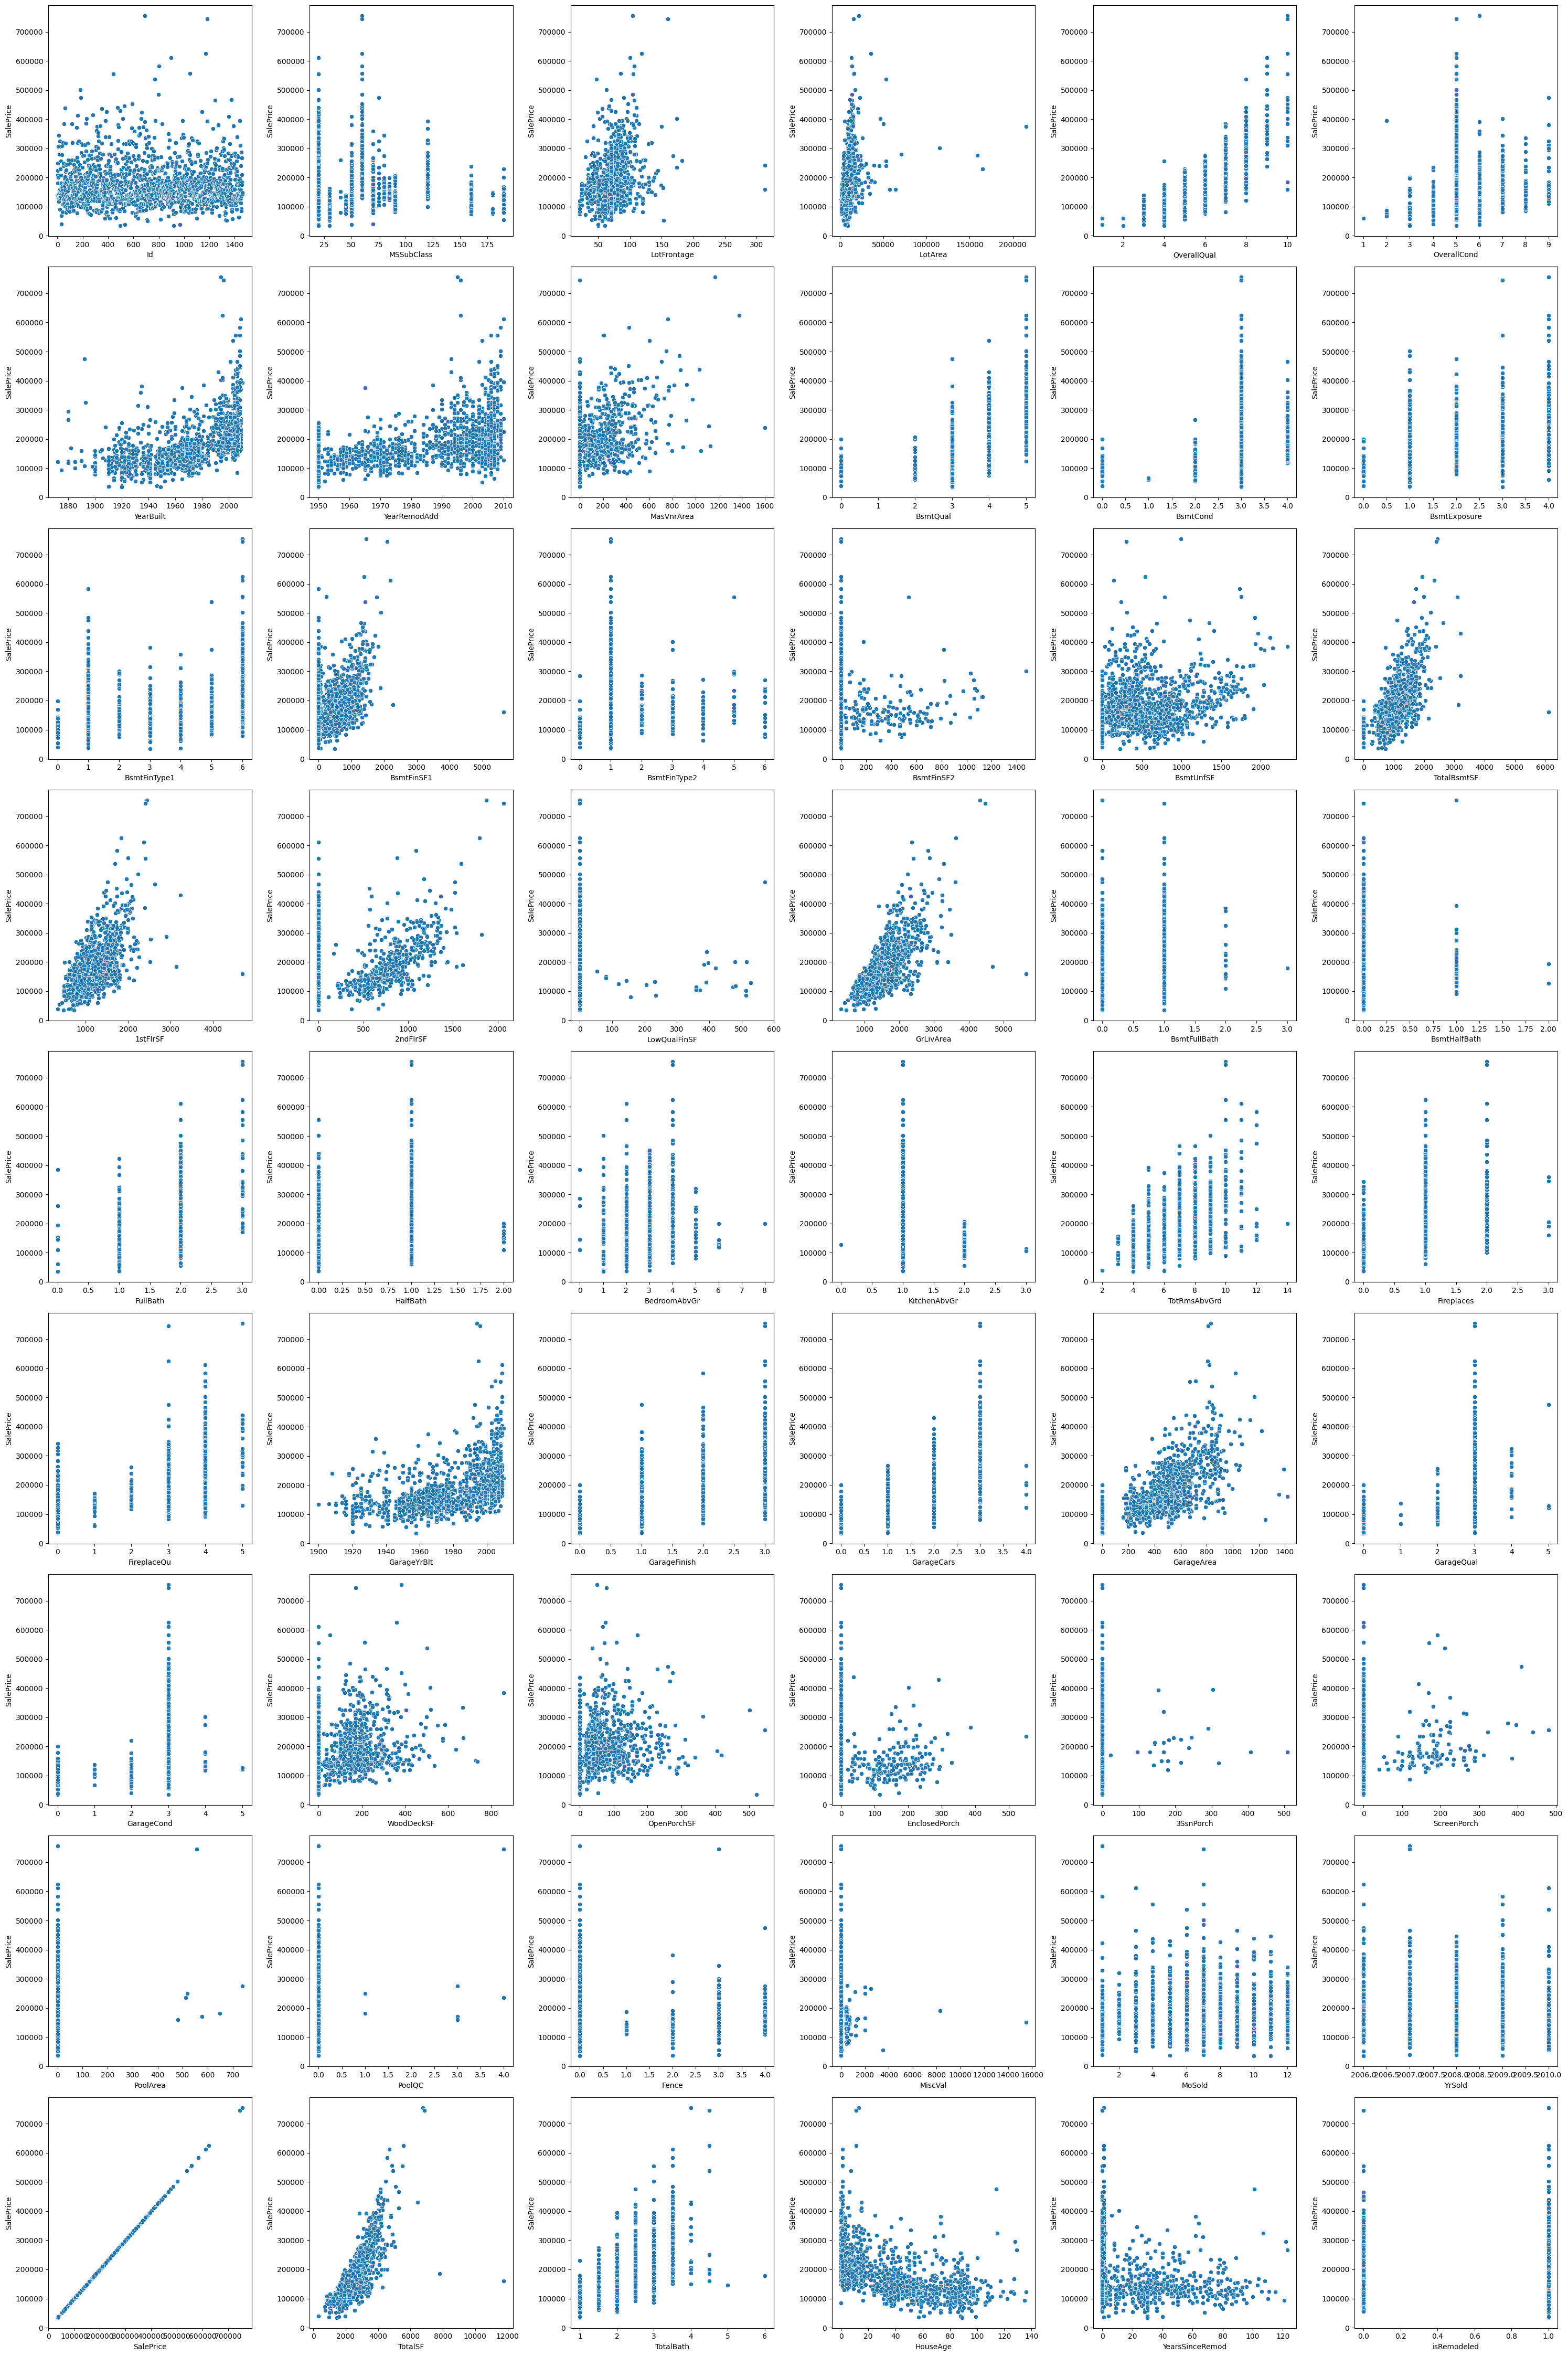

In [ ]:
# Plot scatter plots for all numeric features vs SalePrice to detect outliers
fig, axes = plt.subplots(9, 6, figsize=(30, 45))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y='SalePrice', data=df_train, ax=axes[i])
plt.tight_layout()
plt.show()

In [ ]:
# Identify specific outliers: very large area but low sale price
outliers = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 200000)]
print(outliers[['GrLivArea', 'SalePrice']])

      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [ ]:
# Calculate correlation of all numeric features with SalePrice
correlation = df_train.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)
print(correlation.head(15))  # Top positive correlations
print(correlation.tail(5))   # Top negative correlations

SalePrice       1.000000
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
GarageCars      0.640409
TotalBath       0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
BsmtQual        0.585207
FullBath        0.560664
GarageFinish    0.549247
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
FireplaceQu     0.520438
Name: SalePrice, dtype: float64
EnclosedPorch     -0.128578
KitchenAbvGr      -0.135907
Fence             -0.146942
YearsSinceRemod   -0.217503
HouseAge          -0.523350
Name: SalePrice, dtype: float64


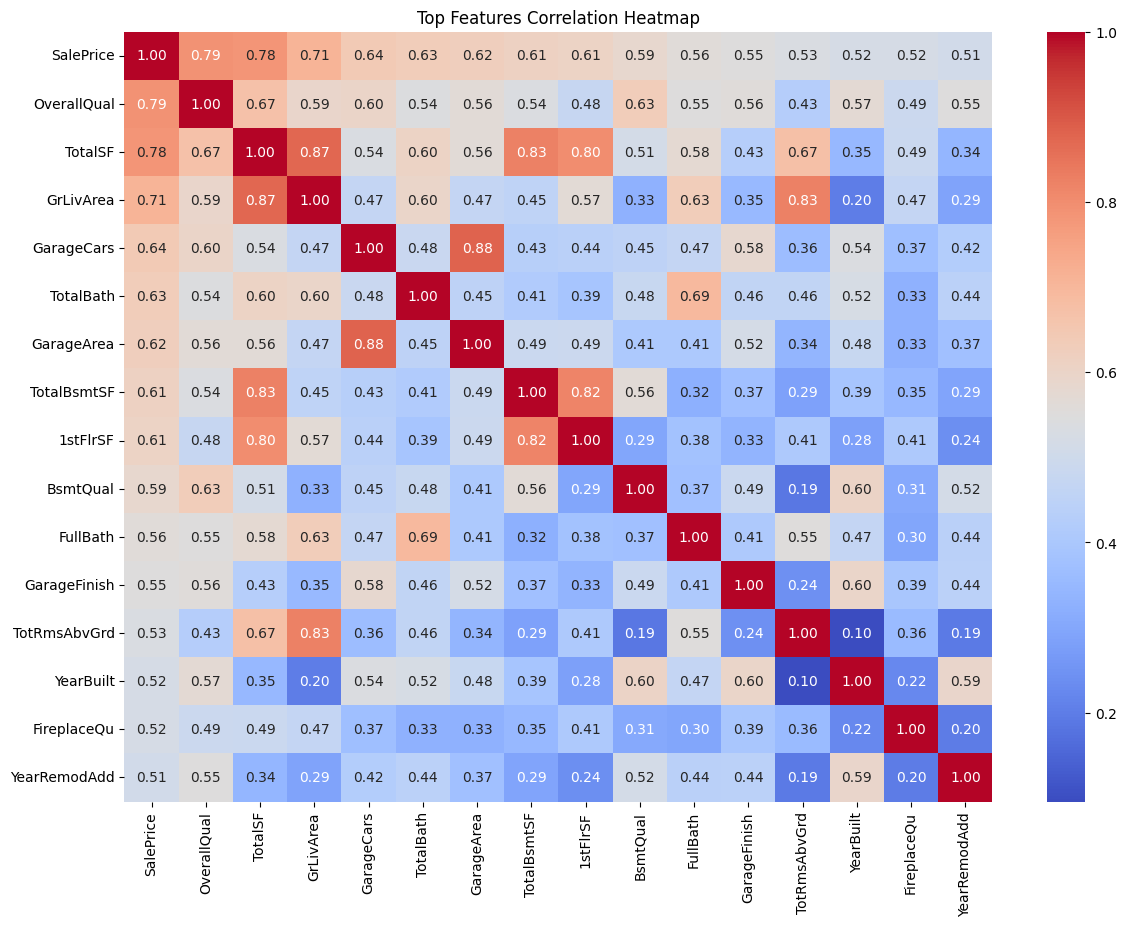

In [ ]:
# Heatmap of the top 15 correlated features to see multi-collinearity
top_features = correlation.head(16).index
plt.figure(figsize=(14, 10))
sns.heatmap(df_train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top Features Correlation Heatmap')
plt.show()

In [ ]:
# Drop Id and redundant features to reduce multi-collinearity
df_train = df_train.drop(columns=['Id'])
cols_to_drop = ['1stFlrSF', 'TotalBsmtSF', 'GarageArea', 'TotRmsAbvGrd']
existing = [col for col in cols_to_drop if col in df_train.columns]
print("Columns to drop:", existing)
df_train = df_train.drop(columns=existing)

print("Shape:", df_train.shape)

Columns to drop: ['1stFlrSF', 'TotalBsmtSF', 'GarageArea', 'TotRmsAbvGrd']
Shape: (1460, 81)


In [ ]:
# Verify current shape of dataframe
print("Shape:", df_train.shape)

Shape: (1460, 81)


In [ ]:
# Create log-transformed target variable for better model fitting
df_train['SalePrice_log'] = np.log1p(df_train['SalePrice'])
print("Shape:", df_train.shape)
print("SalePrice_log created:", 'SalePrice_log' in df_train.columns)

Shape: (1460, 82)
SalePrice_log created: True


In [ ]:
# Apply log transformation to highly skewed numeric features
ordinal_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence']

skewed_cols = []
for col in df_train.select_dtypes(include='number').columns:
    if col not in ['SalePrice', 'SalePrice_log']:
        if abs(df_train[col].skew()) > 0.75:
            skewed_cols.append(col)

# Transform only non-ordinal numeric features with high skew
for col in skewed_cols:
    if col not in ordinal_cols:
        df_train[col] = np.log1p(df_train[col])

print("Skewed cols transformed:", len(skewed_cols))

Skewed cols transformed: 29


In [ ]:
# Check new skewness values after transformation
for col in skewed_cols:
    print(f"{col}: {df_train[col].skew():.2f}")

MSSubClass: 0.25
LotFrontage: -0.89
LotArea: -0.14
MasVnrArea: 0.50
BsmtQual: -1.29
BsmtCond: -3.70
BsmtExposure: 1.10
BsmtFinSF1: -0.62
BsmtFinType2: 3.30
BsmtFinSF2: 2.52
BsmtUnfSF: -2.19
2ndFlrSF: 0.29
LowQualFinSF: 7.46
GrLivArea: -0.01
BsmtHalfBath: 3.93
KitchenAbvGr: 3.87
GarageQual: -3.23
GarageCond: -3.33
WoodDeckSF: 0.15
OpenPorchSF: -0.02
EnclosedPorch: 2.11
3SsnPorch: 7.73
ScreenPorch: 3.15
PoolArea: 14.36
PoolQC: 16.85
Fence: 1.81
MiscVal: 5.17
TotalSF: -0.35
YearsSinceRemod: 0.87


In [ ]:
# Re-calculate correlation with the original SalePrice
correlation = df_train.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)
top_features1 = correlation.head(11).index
print(top_features1)
print(df_train.shape)

Index(['SalePrice', 'SalePrice_log', 'OverallQual', 'TotalSF', 'GrLivArea',
       'GarageCars', 'TotalBath', 'BsmtQual', 'FullBath', 'GarageFinish',
       'YearBuilt'],
      dtype='object')
(1460, 82)


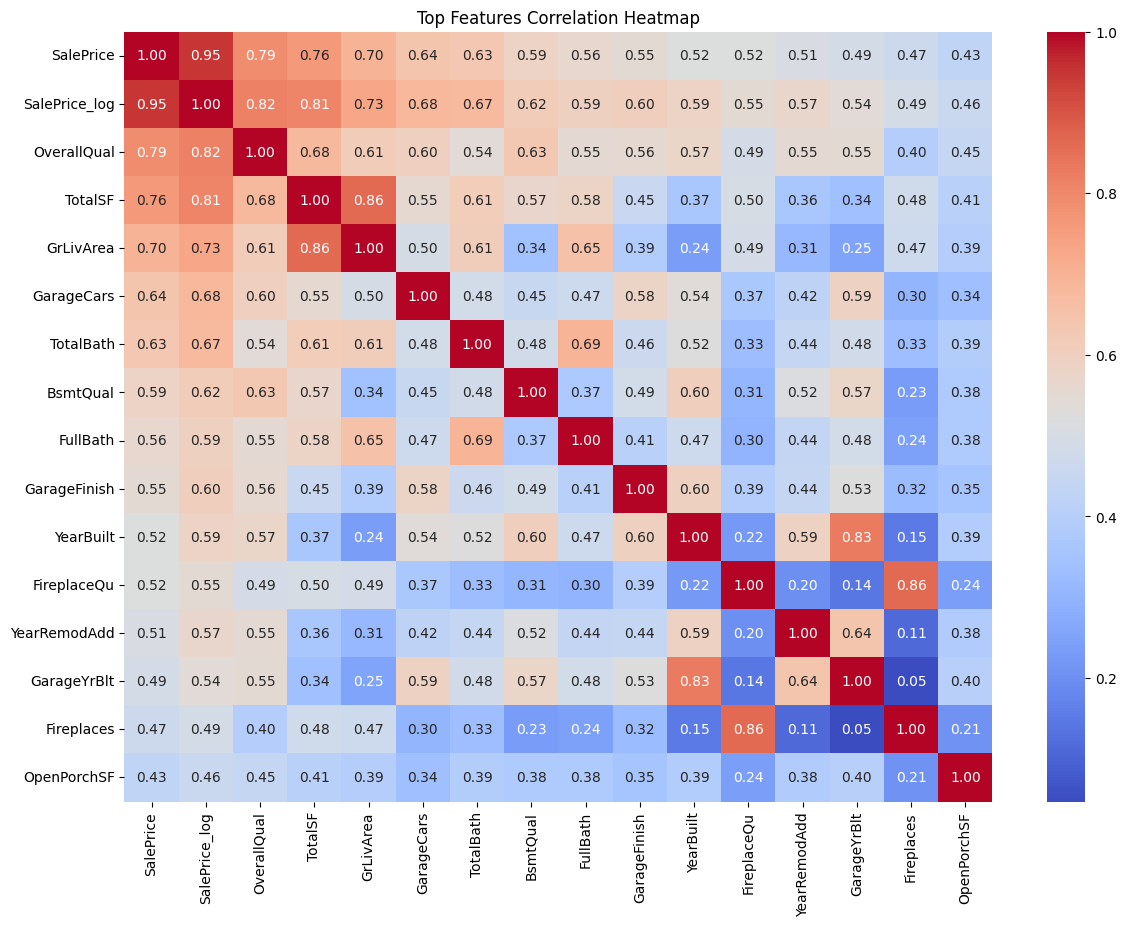

In [ ]:
# Re-plot heatmap for top features after log transformations
top_features1 = correlation.head(16).index
plt.figure(figsize=(14, 10))
sns.heatmap(df_train[top_features1].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top Features Correlation Heatmap')
plt.show()

In [ ]:
# Identify remaining categorical (object) columns
obj_cols = df_train.select_dtypes(include='object').columns
print(obj_cols.tolist())
print("Count:", len(obj_cols))

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']
Count: 32


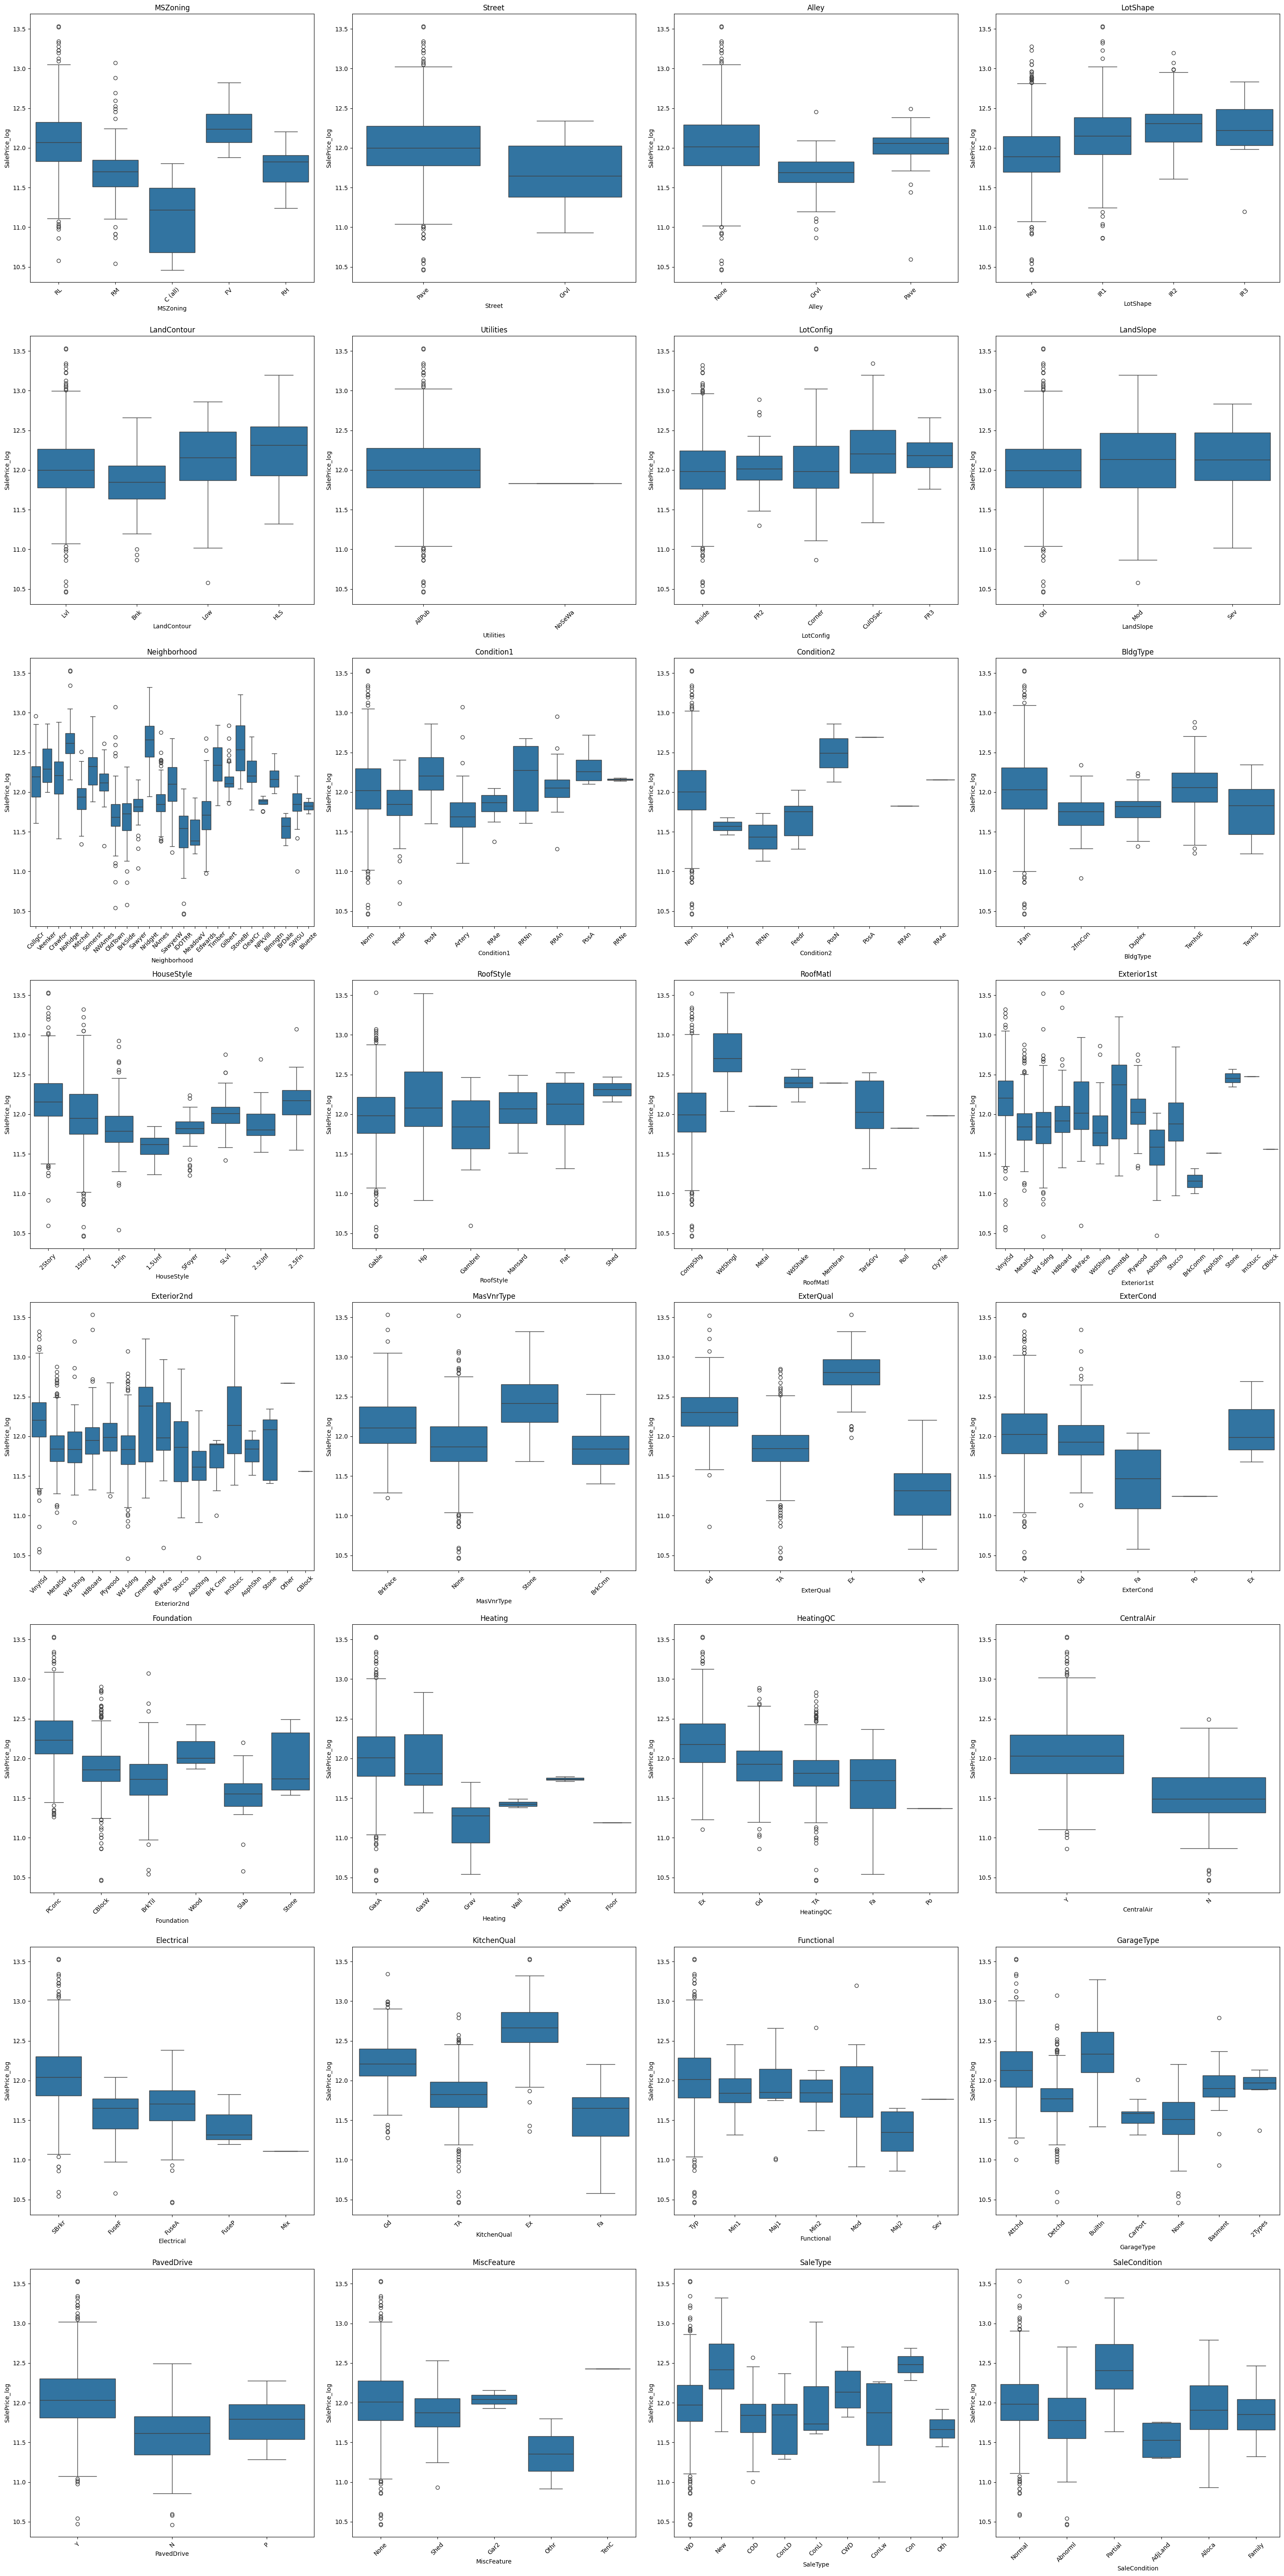

In [ ]:
# Visualize log SalePrice across different categorical levels using boxplots
fig, axes = plt.subplots(8, 4, figsize=(30, 60))
axes = axes.flatten()

for i, col in enumerate(obj_cols):
    sns.boxplot(x=col, y='SalePrice_log', data=df_train, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# One-hot encode categorical variables
df_train = pd.get_dummies(df_train, columns=obj_cols)
print("Shape after encoding:", df_train.shape)

Shape after encoding: (1460, 256)


In [ ]:
# Check correlation with the target log variable after encoding
correlation = df_train.select_dtypes(include='number').corr()['SalePrice_log'].sort_values(ascending=False)
print(correlation.head(15))

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817185
TotalSF          0.807140
GrLivArea        0.730254
GarageCars       0.680625
TotalBath        0.673011
BsmtQual         0.615804
GarageFinish     0.604878
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
FireplaceQu      0.546362
GarageYrBlt      0.541073
Fireplaces       0.489450
Name: SalePrice_log, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
# Prepare features (X) and target (y)
X = df_train.drop(columns=['SalePrice', 'SalePrice_log'])
y = df_train['SalePrice_log']
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1168, 254)
X_val: (292, 254)
y_train: (1168,)
y_val: (292,)


In [ ]:
# Check for any NaNs that might break the model training
print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_val:", X_val.isna().sum().sum())

NaN in X_train: 64
NaN in X_val: 17


In [ ]:
# Identify which columns still have missing values
nan_cols = X_train.columns[X_train.isna().any()].tolist()
print(nan_cols)

['GarageYrBlt']


In [ ]:
# Final fill for GarageYrBlt: 0 is used for houses without garages
X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(0)
X_val['GarageYrBlt'] = X_val['GarageYrBlt'].fillna(0)

print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_val:", X_val.isna().sum().sum())

NaN in X_train: 0
NaN in X_val: 0


In [ ]:
from sklearn.preprocessing import StandardScaler
# Standardize features (Z-score normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Test basic linear models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: RMSE={rmse:.4f}, R²={r2:.4f}")

Linear Regression: RMSE=0.1181, R²=0.9253
Ridge: RMSE=0.1182, R²=0.9251
Lasso: RMSE=0.4332, R²=-0.0058


In [ ]:
from sklearn.model_selection import GridSearchCV
# Hyperparameter tuning for Ridge regression
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train_scaled, y_train)
print("Best alpha:", grid_ridge.best_params_)

Best alpha: {'alpha': 100}


In [ ]:
# Hyperparameter tuning for Lasso regression
grid_lasso = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train_scaled, y_train)
print("Best alpha:", grid_lasso.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.775e-02, tolerance: 1.436e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.632e-02, tolerance: 1.335e-02
  model = cd_fast.enet_coordinate_descent(


Best alpha: {'alpha': 0.001}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.418e-02, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Evaluate tuned models on validation set
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_val_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_val_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
r2_lasso = r2_score(y_val, y_pred_lasso)

print(f"Best Ridge: RMSE={rmse_ridge:.4f}, R²={r2_ridge:.4f}")
print(f"Best Lasso: RMSE={rmse_lasso:.4f}, R²={r2_lasso:.4f}")

Best Ridge: RMSE=0.1193, R²=0.9237
Best Lasso: RMSE=0.1176, R²=0.9259


In [ ]:
# Analyze which features Lasso kept (non-zero coefficients)
importance = pd.Series(best_lasso.coef_, index=X_train.columns)
importance = importance[importance != 0].sort_values(ascending=False)

print(f"Features kept by Lasso: {len(importance)} out of {X_train.shape[1]}")
print("\nTop 10 positive features:")
print(importance.head(10))
print("\nTop 10 negative features:")
print(importance.tail(10))

Features kept by Lasso: 161 out of 254

Top 10 positive features:
GrLivArea               0.089510
TotalSF                 0.071155
OverallQual             0.056531
OverallCond             0.044442
LotArea                 0.040931
GarageCars              0.031355
YearRemodAdd            0.029962
Neighborhood_Crawfor    0.021130
KitchenQual_Ex          0.020822
Neighborhood_StoneBr    0.019667
dtype: float64

Top 10 negative features:
BsmtUnfSF               -0.010031
Functional_Maj2         -0.010701
Heating_Grav            -0.011090
Neighborhood_Edwards    -0.011514
SaleCondition_Abnorml   -0.014320
MSZoning_C (all)        -0.016610
YearsSinceRemod         -0.023660
Condition2_PosN         -0.025990
HouseAge                -0.043308
RoofMatl_ClyTile        -0.048589
dtype: float64


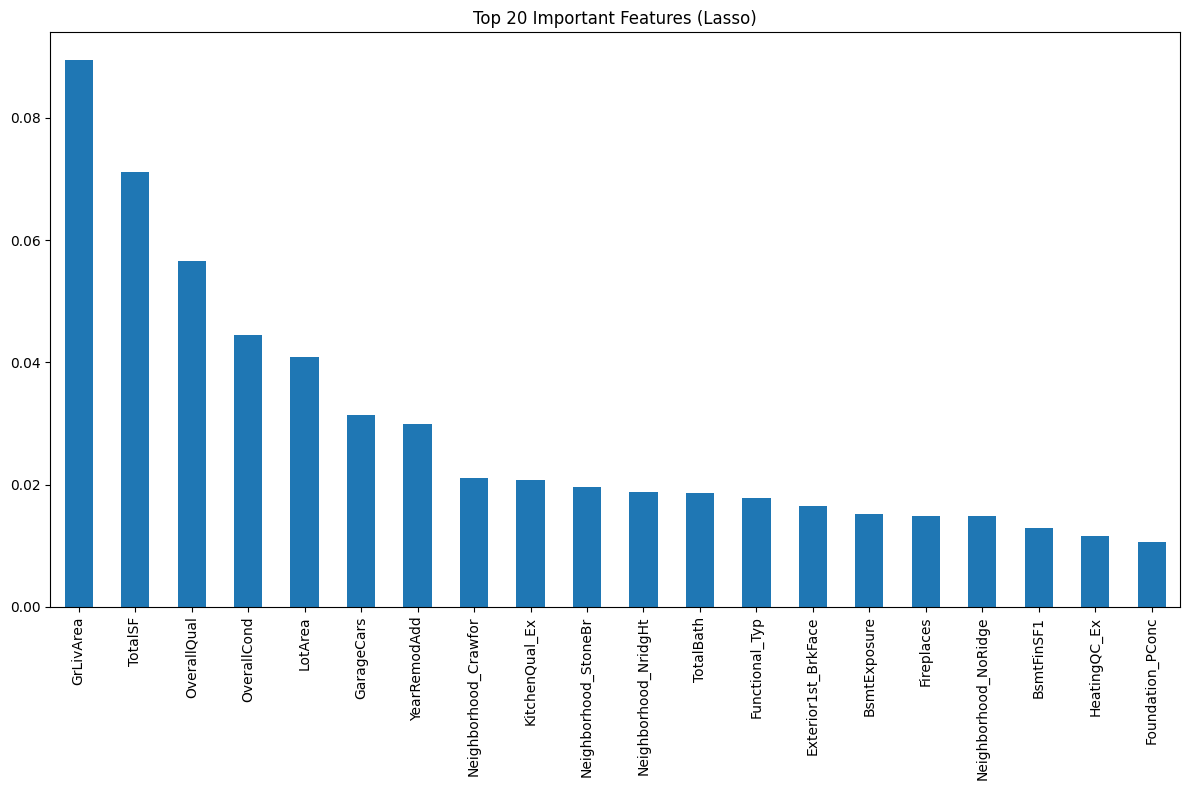

In [ ]:
# Bar plot of feature importance from Lasso
plt.figure(figsize=(12, 8))
importance.head(20).plot(kind='bar')
plt.title('Top 20 Important Features (Lasso)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
# Compare models using 5-fold cross-validation
models_to_eval = {
    'Linear Regression': LinearRegression(),
    'Ridge (tuned)': Ridge(alpha=100),
    'Lasso (tuned)': Lasso(alpha=0.001)
}

for name, model in models_to_eval.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f"{name}:")
    print(f"  RMSE per fold: {rmse_scores.round(4)}")
    print(f"  Mean RMSE: {rmse_scores.mean():.4f}")
    print(f"  Std: {rmse_scores.std():.4f}")

Linear Regression:
  RMSE per fold: [0.1317 0.1462 0.1698 0.1425 0.1075]
  Mean RMSE: 0.1396
  Std: 0.0203
Ridge (tuned):
  RMSE per fold: [0.12   0.134  0.1639 0.1302 0.1043]
  Mean RMSE: 0.1305
  Std: 0.0196


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.775e-02, tolerance: 1.436e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.632e-02, tolerance: 1.335e-02
  model = cd_fast.enet_coordinate_descent(


Lasso (tuned):
  RMSE per fold: [0.1148 0.1362 0.1653 0.1338 0.1035]
  Mean RMSE: 0.1307
  Std: 0.0211


In [ ]:
from xgboost import XGBRegressor
# Evaluate baseline XGBoost using cross-validation
xgb = XGBRegressor(random_state=42)
scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print(f"XGBoost:")
print(f"  RMSE per fold: {rmse_scores.round(4)}")
print(f"  Mean RMSE: {rmse_scores.mean():.4f}")
print(f"  Std: {rmse_scores.std():.4f}")

XGBoost:
  RMSE per fold: [0.1362 0.161  0.1588 0.1419 0.1164]
  Mean RMSE: 0.1429
  Std: 0.0163


In [ ]:
# Hyperparameter tuning for XGBoost
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_xgb.fit(X_train_scaled, y_train)
print("Best params:", grid_xgb.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


In [ ]:
# Evaluate tuned XGBoost model
best_xgb = grid_xgb.best_estimator_
scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print(f"XGBoost (tuned):")
print(f"  Mean RMSE: {rmse_scores.mean():.4f}")
print(f"  Std: {rmse_scores.std():.4f}")

XGBoost (tuned):
  Mean RMSE: 0.1263
  Std: 0.0124


In [ ]:
# Inspect test set missing values
print("Test shape:", df_test.shape)
print("\nMissing values:")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])

Test shape: (1459, 80)

Missing values:
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64


In [ ]:
# Preprocess test set using logic consistent with training set
# 1. Fill numeric values with median or constant
df_test['LotFrontage'] = df_test['LotFrontage'].fillna(df_test['LotFrontage'].median())
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(0)
df_test['GarageYrBlt'] = df_test['GarageYrBlt'].fillna(0)
df_test['BsmtFinSF1'] = df_test['BsmtFinSF1'].fillna(0)
df_test['BsmtFinSF2'] = df_test['BsmtFinSF2'].fillna(0)
df_test['BsmtUnfSF'] = df_test['BsmtUnfSF'].fillna(0)
df_test['TotalBsmtSF'] = df_test['TotalBsmtSF'].fillna(0)
df_test['BsmtFullBath'] = df_test['BsmtFullBath'].fillna(0)
df_test['BsmtHalfBath'] = df_test['BsmtHalfBath'].fillna(0)
df_test['GarageCars'] = df_test['GarageCars'].fillna(0)
df_test['GarageArea'] = df_test['GarageArea'].fillna(0)

# 2. Fill categorical values with mode
df_test['MSZoning'] = df_test['MSZoning'].fillna(df_test['MSZoning'].mode()[0])
df_test['Utilities'] = df_test['Utilities'].fillna(df_test['Utilities'].mode()[0])
df_test['Exterior1st'] = df_test['Exterior1st'].fillna(df_test['Exterior1st'].mode()[0])
df_test['Exterior2nd'] = df_test['Exterior2nd'].fillna(df_test['Exterior2nd'].mode()[0])
df_test['MasVnrType'] = df_test['MasVnrType'].fillna('None')
df_test['KitchenQual'] = df_test['KitchenQual'].fillna(df_test['KitchenQual'].mode()[0])
df_test['Functional'] = df_test['Functional'].fillna(df_test['Functional'].mode()[0])
df_test['SaleType'] = df_test['SaleType'].fillna(df_test['SaleType'].mode()[0])

# 3. Handle ordinals
ordinal_cols_map = {
    'BsmtQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'PoolQC': {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Fence': {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
}

for col, mapping in ordinal_cols_map.items():
    df_test[col] = df_test[col].fillna('None').map(mapping)

# 4. Nominal constants
nominal_none = ['Alley', 'GarageType', 'MiscFeature']
for col in nominal_none:
    df_test[col] = df_test[col].fillna('None')

print("Missing after preprocessing:", df_test.isnull().sum().sum())

Missing after preprocessing: 0


In [ ]:
# Feature Engineering on test set
df_test['TotalSF'] = df_test['TotalBsmtSF'] + df_test['1stFlrSF'] + df_test['2ndFlrSF']
df_test['TotalBath'] = (df_test['FullBath'] + df_test['BsmtFullBath'] + df_test['HalfBath'] * 0.5 + df_test['BsmtHalfBath'] * 0.5)
df_test['HouseAge'] = df_test['YrSold'] - df_test['YearBuilt']
df_test['YearsSinceRemod'] = df_test['YearRemodAdd'] - df_test['YearBuilt']
df_test['isRemodeled'] = df_test['YearsSinceRemod'].apply(lambda x: 1 if x > 0 else 0)

# Ensure no negative ages due to data entry errors
df_test['HouseAge'] = df_test['HouseAge'].clip(lower=0)
df_test['YearsSinceRemod'] = df_test['YearsSinceRemod'].clip(lower=0)

print("Shape after feature engineering:", df_test.shape)

Shape after feature engineering: (1459, 85)


In [ ]:
# Drop redundant columns from test set to match training features
cols_to_drop = ['Id', '1stFlrSF', 'TotalBsmtSF', 'GarageArea', 'TotRmsAbvGrd']
existing = [col for col in cols_to_drop if col in df_test.columns]
df_test = df_test.drop(columns=existing)

print("Shape after dropping:", df_test.shape)

Shape after dropping: (1459, 80)


In [ ]:
# Apply log transformations to the same skewed columns identified in training
for col in skewed_cols:
    if col in df_test.columns and col not in ordinal_cols:
        df_test[col] = np.log1p(df_test[col])

print("Shape:", df_test.shape)

Shape: (1459, 80)


In [ ]:
# One-hot encode test set categorical variables
df_test = pd.get_dummies(df_test, columns=df_test.select_dtypes(include='object').columns)
print("Shape after encoding:", df_test.shape)

Shape after encoding: (1459, 238)


In [ ]:
# Align test columns with training columns (add missing columns as 0s)
df_test = df_test.reindex(columns=X_train.columns, fill_value=0)
print("Shape after alignment:", df_test.shape)

Shape after alignment: (1459, 254)


In [ ]:
# Final missing fill and scaling using the fitted training scaler
df_test['GarageYrBlt'] = df_test['GarageYrBlt'].fillna(0)
df_test_scaled = scaler.transform(df_test)

print("Test scaled shape:", df_test_scaled.shape)

Test scaled shape: (1459, 254)


In [ ]:
# Generate predictions on test set using the tuned XGBoost model
predictions_log = best_xgb.predict(df_test_scaled)
# Revert log transformation to get actual price values
predictions = np.expm1(predictions_log)

print("Predictions shape:", predictions.shape)
print("Sample predictions:", predictions[:5])

Predictions shape: (1459,)
Sample predictions: [123719.29 162403.08 189229.4  191452.14 188411.86]


In [ ]:
# Create the submission CSV file
test_ids = pd.read_csv('test.csv')['Id']
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': predictions})
submission.to_csv('submission.csv', index=False)
print("Submission file created!")
print(submission.head())

Submission file created!
     Id      SalePrice
0  1461  123719.289062
1  1462  162403.078125
2  1463  189229.406250
3  1464  191452.140625
4  1465  188411.859375


In [ ]:
# Evaluate overfitting by comparing train vs validation performance
y_pred_train = best_xgb.predict(X_train_scaled)
y_pred_val = best_xgb.predict(X_val_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
train_r2 = r2_score(y_train, y_pred_train)
val_r2 = r2_score(y_val, y_pred_val)

print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")

Train RMSE: 0.0547 | Val RMSE: 0.1282
Train R²:   0.9804 | Val R²:   0.9119


In [ ]:
# Experiment with more regularization in XGBoost (v2)
best_xgb_v2 = XGBRegressor(
    learning_rate=0.05, n_estimators=500, max_depth=3, subsample=0.8,
    reg_alpha=0.1, reg_lambda=1.5, min_child_weight=3, random_state=42
)
best_xgb_v2.fit(X_train_scaled, y_train)

train_r2 = r2_score(y_train, best_xgb_v2.predict(X_train_scaled))
val_r2 = r2_score(y_val, best_xgb_v2.predict(X_val_scaled))

print(f"Train R²: {train_r2:.4f}")
print(f"Val R²:   {val_r2:.4f}")

Train R²: 0.9778
Val R²:   0.9120


In [ ]:
# Experiment with heavy regularization in XGBoost (v3)
best_xgb_v3 = XGBRegressor(
    learning_rate=0.05, n_estimators=500, max_depth=3, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=1, reg_lambda=2, min_child_weight=5, gamma=0.1, random_state=42
)
best_xgb_v3.fit(X_train_scaled, y_train)

train_rmse = np.sqrt(mean_squared_error(y_train, best_xgb_v3.predict(X_train_scaled)))
val_rmse = np.sqrt(mean_squared_error(y_val, best_xgb_v3.predict(X_val_scaled)))
train_r2 = r2_score(y_train, best_xgb_v3.predict(X_train_scaled))
val_r2 = r2_score(y_val, best_xgb_v3.predict(X_val_scaled))

print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")

Train RMSE: 0.1064 | Val RMSE: 0.1386
Train R²:   0.9258 | Val R²:   0.8971


In [ ]:
# Experiment with moderate regularization (v4)
best_xgb_v4 = XGBRegressor(
    learning_rate=0.05, n_estimators=500, max_depth=3, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.5, min_child_weight=3, gamma=0.05, random_state=42
)
best_xgb_v4.fit(X_train_scaled, y_train)

train_rmse = np.sqrt(mean_squared_error(y_train, best_xgb_v4.predict(X_train_scaled)))
val_rmse = np.sqrt(mean_squared_error(y_val, best_xgb_v4.predict(X_val_scaled)))
train_r2 = r2_score(y_train, best_xgb_v4.predict(X_train_scaled))
val_r2 = r2_score(y_val, best_xgb_v4.predict(X_val_scaled))

print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")

Train RMSE: 0.0914 | Val RMSE: 0.1333
Train R²:   0.9452 | Val R²:   0.9048


In [ ]:
# Final evaluation of the tuned Lasso model
y_pred_train_lasso = best_lasso.predict(X_train_scaled)
y_pred_val_lasso = best_lasso.predict(X_val_scaled)

train_r2 = r2_score(y_train, y_pred_train_lasso)
val_r2 = r2_score(y_val, y_pred_val_lasso)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val_lasso))

print(f"Lasso Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
print(f"Lasso Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")

Lasso Train RMSE: 0.0930 | Val RMSE: 0.1176
Lasso Train R²:   0.9433 | Val R²:   0.9259


In [ ]:
# Create alternative submission file using the Lasso model
predictions_log = best_lasso.predict(df_test_scaled)
predictions = np.expm1(predictions_log)
submission = pd.DataFrame({'Id': pd.read_csv('test.csv')['Id'], 'SalePrice': predictions})
submission.to_csv('submission_lasso.csv', index=False)
print(submission.head())

     Id      SalePrice
0  1461  117508.167216
1  1462  156685.067961
2  1463  183647.861151
3  1464  193191.898345
4  1465  208366.050855


In [ ]:
from google.colab import files
# Download the Lasso submission file to local machine
files.download('submission_lasso.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>